In [ ]:
from google.colab import files
uploaded = files.upload()   # Telco-Customer-Churn.csv ah select pannunga

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# TotalCharges ah numeric ah convert pannuvom
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Ethana rows null aachu-nu paakalam
print(df['TotalCharges'].isnull().sum())

# Andha rows ah paarunga - tenure 0 iruka nu check pannunga
df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges','TotalCharges']]

11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [ ]:
df = df.dropna(subset=['TotalCharges'])
print(df.shape)   # 7032 rows expected

# customerID drop pannuvom - andha column model ku use illa
df.drop('customerID', axis=1, inplace=True)

# Duplicate check
print("Duplicates:", df.duplicated().sum())

(7032, 21)
Duplicates: 22


In [ ]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [ ]:
# Pandas dataframe ah SQLite database ah convert pannuvom
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')

# Query 1: Contract type wise churn rate
q1 = """
SELECT Contract,
       COUNT(*) as total_customers,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
       ROUND(100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) as churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""
print(pd.read_sql(q1, conn))

# Query 2: Tenure buckets (loyalty/recharge-frequency proxy) wise churn
q2 = """
SELECT
  CASE
    WHEN tenure <= 12 THEN '0-1 year'
    WHEN tenure <= 24 THEN '1-2 years'
    WHEN tenure <= 48 THEN '2-4 years'
    ELSE '4+ years'
  END as tenure_group,
  COUNT(*) as total,
  ROUND(AVG(MonthlyCharges),2) as avg_monthly_charge,
  ROUND(100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) as churn_rate_pct
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate_pct DESC
"""
print(pd.read_sql(q2, conn))

# Query 3: Payment method wise churn (billing pattern)
q3 = """
SELECT PaymentMethod,
       COUNT(*) as total,
       ROUND(AVG(MonthlyCharges),2) as avg_charge,
       ROUND(100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) as churn_rate_pct
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate_pct DESC
"""
print(pd.read_sql(q3, conn))

         Contract  total_customers  churned  churn_rate_pct
0  Month-to-month             3875     1655           42.71
1        One year             1472      166           11.28
2        Two year             1685       48            2.85
  tenure_group  total  avg_monthly_charge  churn_rate_pct
0     0-1 year   2175               56.17           47.68
1    1-2 years   1024               61.36           28.71
2    2-4 years   1594               65.93           20.39
3     4+ years   2239               73.95            9.51
               PaymentMethod  total  avg_charge  churn_rate_pct
0           Electronic check   2365       76.26           45.29
1               Mailed check   1604       43.96           19.20
2  Bank transfer (automatic)   1542       67.21           16.73
3    Credit card (automatic)   1521       66.52           15.25


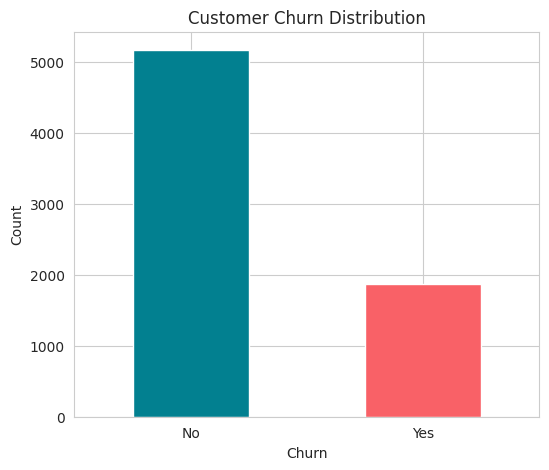

In [ ]:
plt.figure(figsize=(6,5))
df['Churn'].value_counts().plot(kind='bar', color=['#028090','#F96167'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

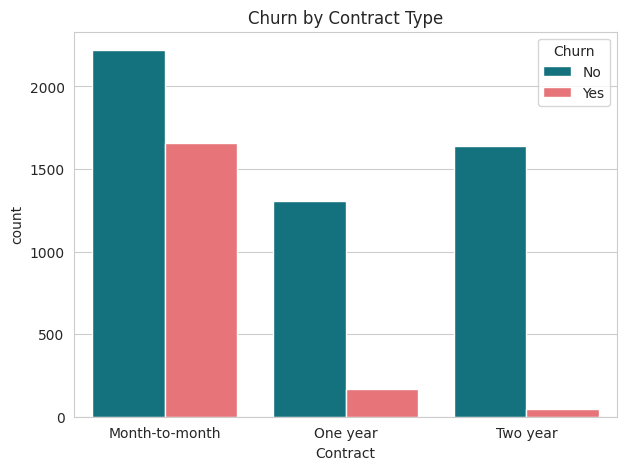

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#028090','#F96167'])
plt.title('Churn by Contract Type')
plt.show()

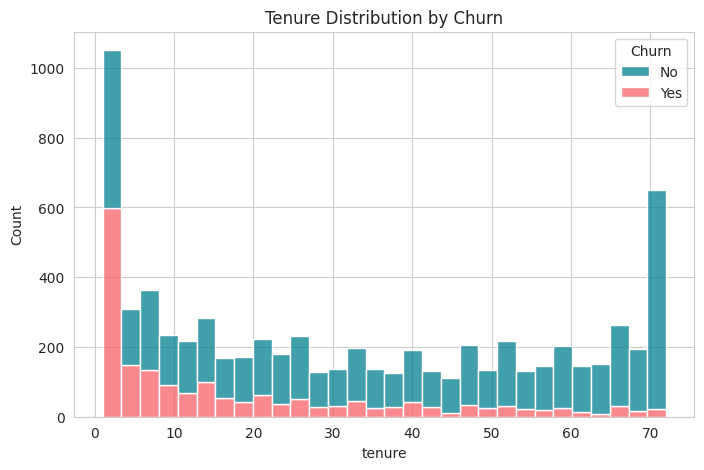

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette=['#028090','#F96167'])
plt.title('Tenure Distribution by Churn')
plt.show()

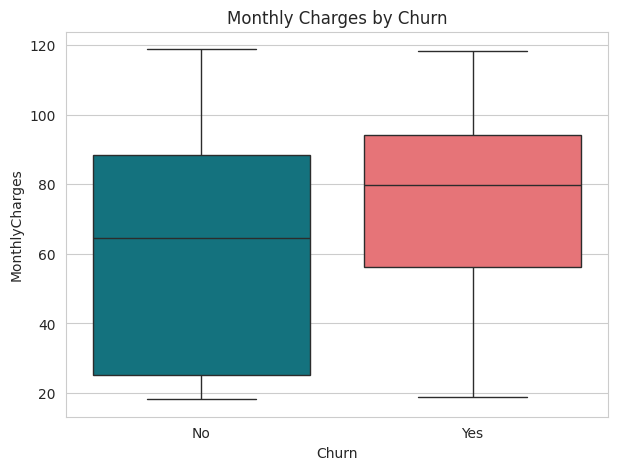

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#028090','#F96167'])
plt.title('Monthly Charges by Churn')
plt.show()

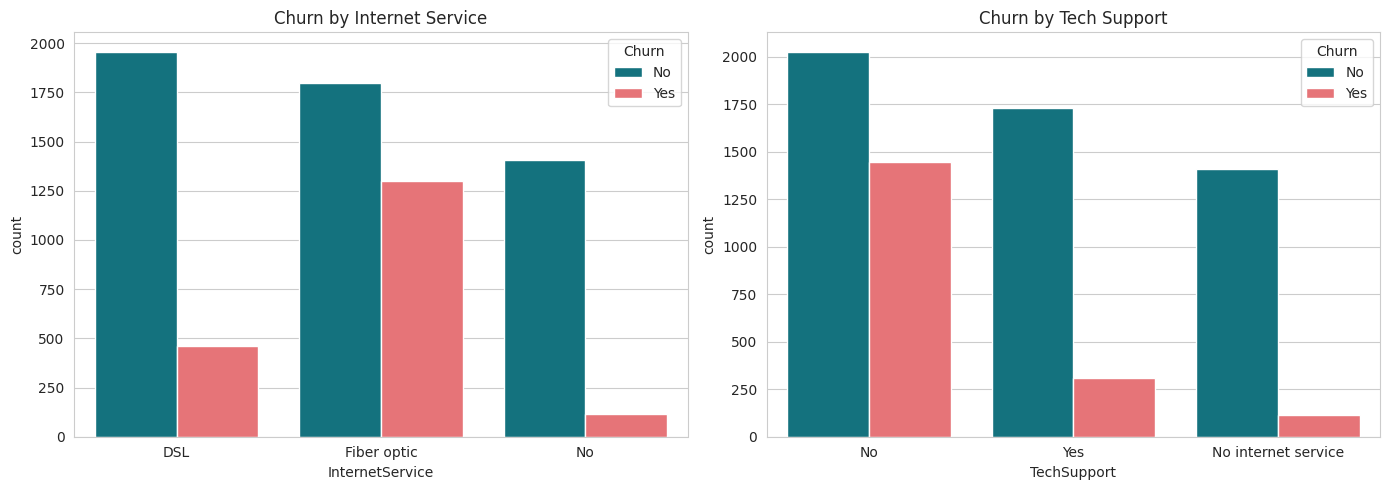

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0], palette=['#028090','#F96167'])
axes[0].set_title('Churn by Internet Service')
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1], palette=['#028090','#F96167'])
axes[1].set_title('Churn by Tech Support')
plt.tight_layout()
plt.show()

In [ ]:
df_model = df.copy()

# Binary columns ah 0/1 ah convert pannuvom
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes':1, 'No':0})

df_model['gender'] = df_model['gender'].map({'Male':1, 'Female':0})

# Multi-category columns ah one-hot encoding pannuvom
multi_cat_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                   'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                   'Contract','PaymentMethod']

df_model = pd.get_dummies(df_model, columns=multi_cat_cols, drop_first=True)

print(df_model.shape)
df_model.head()

(7032, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Train: (5625, 30)  Test: (1407, 30)
Train churn rate: 0.2657777777777778
Test churn rate: 0.2658137882018479


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1]))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8356727976766699

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.8377590321528592


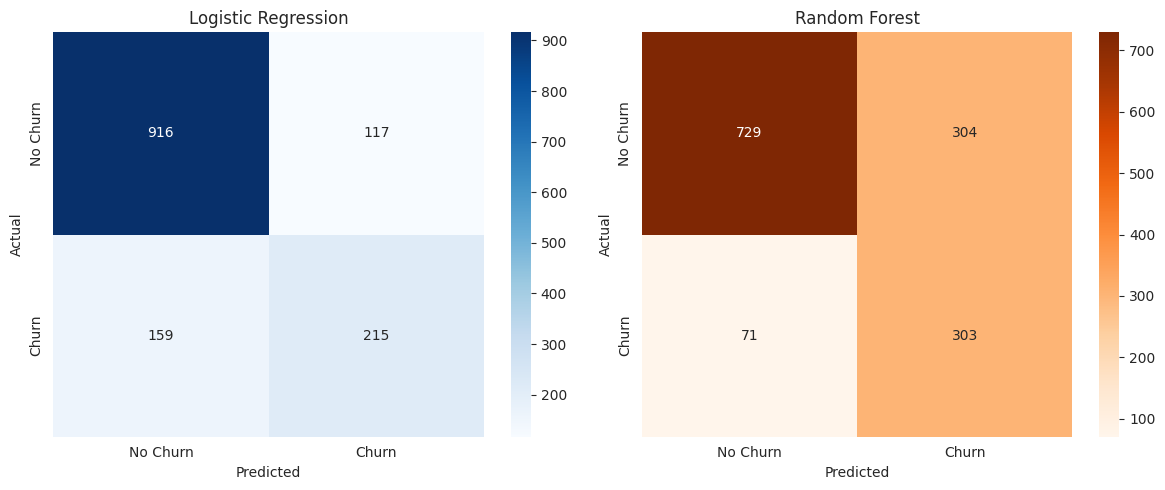

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

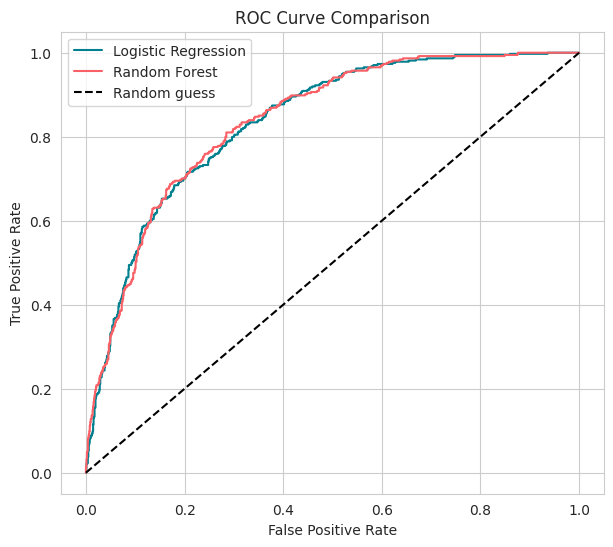

In [ ]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression', color='#028090')
plt.plot(fpr_rf, tpr_rf, label='Random Forest', color='#F96167')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [ ]:
final_model = rf_model   # your best model

In [ ]:
!pip install eli5 -q
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(rf_model, random_state=42).fit(X_test, y_test)
eli5.show_weights(perm, feature_names=X_test.columns.tolist(), top=15)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.8 MB/s eta 0:00:00


Weight,Feature
0.0087 ± 0.0145,tenure
0.0051 ± 0.0045,Contract_One year
0.0040 ± 0.0057,OnlineSecurity_Yes
0.0017 ± 0.0014,DeviceProtection_Yes
0.0017 ± 0.0026,TechSupport_Yes
0.0007 ± 0.0009,SeniorCitizen
0.0007 ± 0.0025,gender
0.0000 ± 0.0025,PaperlessBilling
0.0000 ± 0.0020,Partner
-0.0001 ± 0.0011,MultipleLines_No phone service


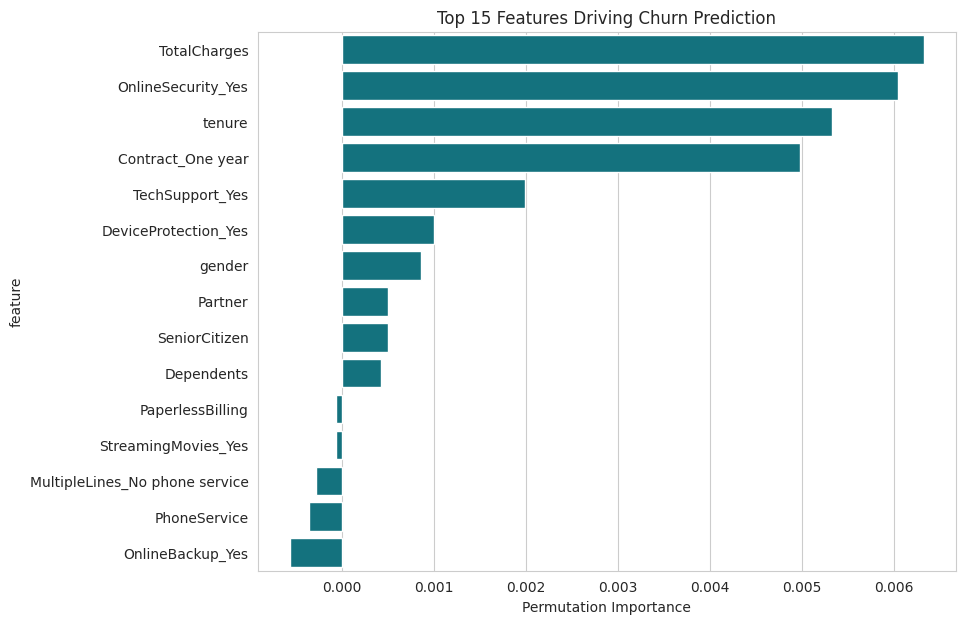

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9,7))
sns.barplot(data=importance_df, x='importance', y='feature', color='#028090')
plt.title('Top 15 Features Driving Churn Prediction')
plt.xlabel('Permutation Importance')
plt.show()

In [ ]:
# Full dataset ku churn probability predict pannuvom
X_full = df_model.drop('Churn', axis=1)
df['churn_probability'] = rf_model.predict_proba(X_full)[:,1]

# Segmentation logic
def segment_customer(row):
    if row['churn_probability'] >= 0.5:
        return 'At Risk'
    elif row['tenure'] >= 24 and row['churn_probability'] < 0.3:
        return 'Loyal'
    else:
        return 'Dormant'

df['Customer_Segment'] = df.apply(segment_customer, axis=1)

print(df['Customer_Segment'].value_counts())
print(df['Customer_Segment'].value_counts(normalize=True)*100)

Customer_Segment
At Risk    2900
Loyal      2230
Dormant    1902
Name: count, dtype: int64
Customer_Segment
At Risk    41.240046
Loyal      31.712173
Dormant    27.047782
Name: proportion, dtype: float64


In [ ]:
segment_summary = df.groupby('Customer_Segment').agg(
    count=('tenure','count'),
    avg_tenure=('tenure','mean'),
    avg_monthly_charge=('MonthlyCharges','mean'),
    avg_churn_prob=('churn_probability','mean'),
    actual_churn_rate=('Churn', lambda x: (x=='Yes').mean()*100)
).round(2)

print(segment_summary)

                  count  avg_tenure  avg_monthly_charge  avg_churn_prob  \
Customer_Segment                                                          
At Risk            2900       15.71               74.52            0.69   
Dormant            1902       30.51               58.66            0.33   
Loyal              2230       55.78               57.39            0.13   

                  actual_churn_rate  
Customer_Segment                     
At Risk                       53.17  
Dormant                       13.67  
Loyal                          3.00  


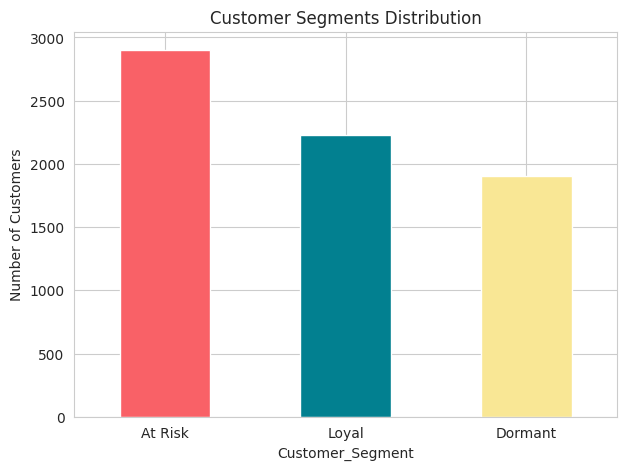

In [ ]:
plt.figure(figsize=(7,5))
df['Customer_Segment'].value_counts().plot(kind='bar', color=['#F96167','#028090','#F9E795'])
plt.title('Customer Segments Distribution')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

## Final Recommendations

**1. At Risk Segment (Highest Priority)**
- Offer discounts or incentives to month-to-month customers to encourage them to switch to 1-year or 2-year contracts, since long-term contracts show significantly lower churn
- Provide free trials of OnlineSecurity and TechSupport to customers who don't have these services — data shows customers without these services churn more
- Offer personalized retention calls or loyalty discounts to customers with high MonthlyCharges, as high billing correlates with higher churn

**2. Loyal Segment (Retain & Reward)**
- Introduce referral programs and loyalty points to turn these customers into brand advocates
- Cross-sell additional services (StreamingTV, StreamingMovies) to increase their engagement and revenue

**3. Dormant Segment (Re-engage)**
- Send personalized offers based on usage patterns to increase engagement
- Run feedback surveys to identify dissatisfaction reasons before they become "At Risk"

**4. Payment Method Insight**
- Customers using Electronic Check show higher churn rates — offer a small incentive to switch to automatic payment methods (credit card/bank transfer), which show lower churn

**5. Business Impact**
- By proactively targeting the "At Risk" segment with retention campaigns, the company could reduce churn by an estimated 5-10%, preventing significant revenue loss

In [ ]:
import joblib

# Model save pannuvom
joblib.dump(rf_model, 'churn_model.pkl')

# Segmented data ah CSV ah save pannuvom
df.to_csv('churn_with_segments.csv', index=False)

print("Saved successfully!")
print(df[['tenure','MonthlyCharges','Churn','churn_probability','Customer_Segment']].head())

Saved successfully!
   tenure  MonthlyCharges Churn  churn_probability Customer_Segment
0       1           29.85    No           0.743058          At Risk
1      34           56.95    No           0.221407            Loyal
2       2           53.85   Yes           0.644954          At Risk
3      45           42.30    No           0.198573            Loyal
4       2           70.70   Yes           0.836557          At Risk


In [ ]:
from google.colab import files
files.download('churn_with_segments.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install python-pptx -q
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

print("Ready!")

Ready!


In [ ]:
slide_layout = prs.slide_layouts[6]  # blank layout
slide = prs.slides.add_slide(slide_layout)

# Background color
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0x02, 0x28, 0x33)

# Title
title_box = slide.shapes.add_textbox(Inches(1), Inches(2.8), Inches(11.3), Inches(1.5))
tf = title_box.text_frame
tf.text = "Customer Churn Analysis"
tf.paragraphs[0].font.size = Pt(44)
tf.paragraphs[0].font.bold = True
tf.paragraphs[0].font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)
tf.paragraphs[0].alignment = PP_ALIGN.CENTER

# Subtitle
sub_box = slide.shapes.add_textbox(Inches(1), Inches(4.2), Inches(11.3), Inches(0.8))
tf2 = sub_box.text_frame
tf2.text = "Telecom Industry | Predictive Analytics & Customer Retention Strategy"
tf2.paragraphs[0].font.size = Pt(20)
tf2.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x80, 0x90)
tf2.paragraphs[0].alignment = PP_ALIGN.CENTER

print("Slide 1 done")

Slide 1 done


In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

# Heading
h = slide.shapes.add_textbox(Inches(0.6), Inches(0.4), Inches(12), Inches(0.8))
h.text_frame.text = "Agenda"
h.text_frame.paragraphs[0].font.size = Pt(32)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

agenda_items = [
    "Business Problem & Objective",
    "Dataset Overview",
    "Key Insights from EDA",
    "Churn Prediction Model & Performance",
    "Feature Importance (Explainability)",
    "Customer Segmentation",
    "Recommendations"
]

body = slide.shapes.add_textbox(Inches(1), Inches(1.5), Inches(10), Inches(5))
tf = body.text_frame
tf.word_wrap = True
for i, item in enumerate(agenda_items):
    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
    p.text = f"{i+1}.  {item}"
    p.font.size = Pt(22)
    p.font.color.rgb = RGBColor(0x02, 0x28, 0x33)
    p.space_after = Pt(14)

print("Slide 2 done")

Slide 2 done


In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

h = slide.shapes.add_textbox(Inches(0.6), Inches(0.4), Inches(12), Inches(0.8))
h.text_frame.text = "Business Problem & Objective"
h.text_frame.paragraphs[0].font.size = Pt(32)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

points = [
    "Telecom industry is highly competitive — acquiring a new customer costs 5-25x more than retaining an existing one",
    "Objective: Predict which customers are likely to churn before it happens",
    "Use SQL aggregation + Machine Learning classification to identify at-risk customers",
    "Segment customers (At Risk, Loyal, Dormant) to enable targeted retention strategies",
    "Deliver actionable, data-driven recommendations to reduce churn"
]

body = slide.shapes.add_textbox(Inches(0.8), Inches(1.6), Inches(11.5), Inches(5))
tf = body.text_frame
tf.word_wrap = True
for i, pt in enumerate(points):
    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
    p.text = f"•  {pt}"
    p.font.size = Pt(19)
    p.font.color.rgb = RGBColor(0x33, 0x33, 0x33)
    p.space_after = Pt(16)

print("Slide 3 done")

Slide 3 done


In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

h = slide.shapes.add_textbox(Inches(0.6), Inches(0.4), Inches(12), Inches(0.8))
h.text_frame.text = "Dataset Overview"
h.text_frame.paragraphs[0].font.size = Pt(32)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

stats = [
    ("Total Customers", "7,032"),
    ("Features", "21 (demographics, services, billing, contract)"),
    ("Target Variable", "Churn (Yes / No)"),
    ("Overall Churn Rate", "~26.5%"),
    ("Source", "Telco Customer Churn Dataset"),
]

top = 1.7
for label, value in stats:
    box = slide.shapes.add_textbox(Inches(1), Inches(top), Inches(11.3), Inches(0.7))
    tf = box.text_frame
    tf.text = f"{label}:  {value}"
    tf.paragraphs[0].font.size = Pt(21)
    tf.paragraphs[0].font.bold = True
    tf.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x80, 0x90)
    top += 0.85

print("Slide 4 done")

Slide 4 done


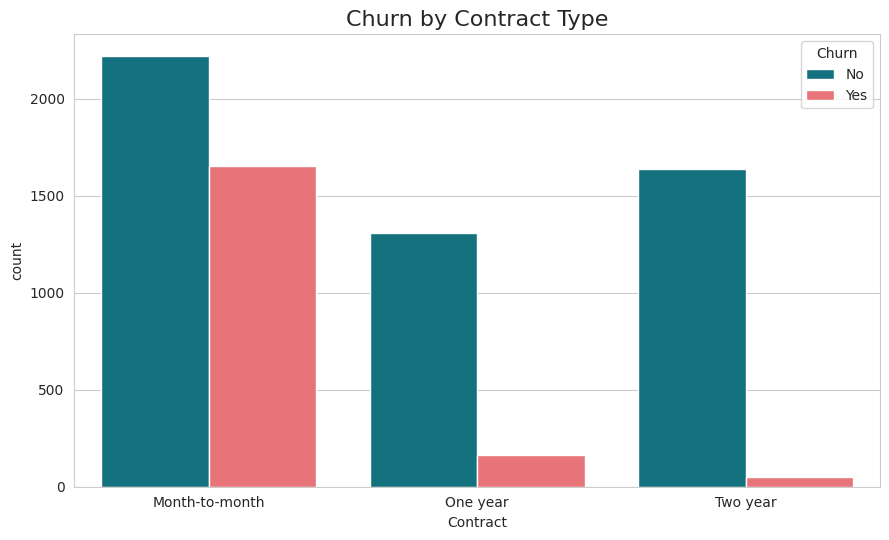

In [ ]:
plt.figure(figsize=(9,5.5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#028090','#F96167'])
plt.title('Churn by Contract Type', fontsize=16)
plt.tight_layout()
plt.savefig('chart_contract.png', dpi=150)
plt.show()

In [ ]:
print(df.shape)

(7032, 20)


In [ ]:
!pip install python-pptx -q
from pptx import Presentation
from pptx.util import Inches, Pt, Emu
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

print("Ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.9 MB/s eta 0:00:00
Ready!


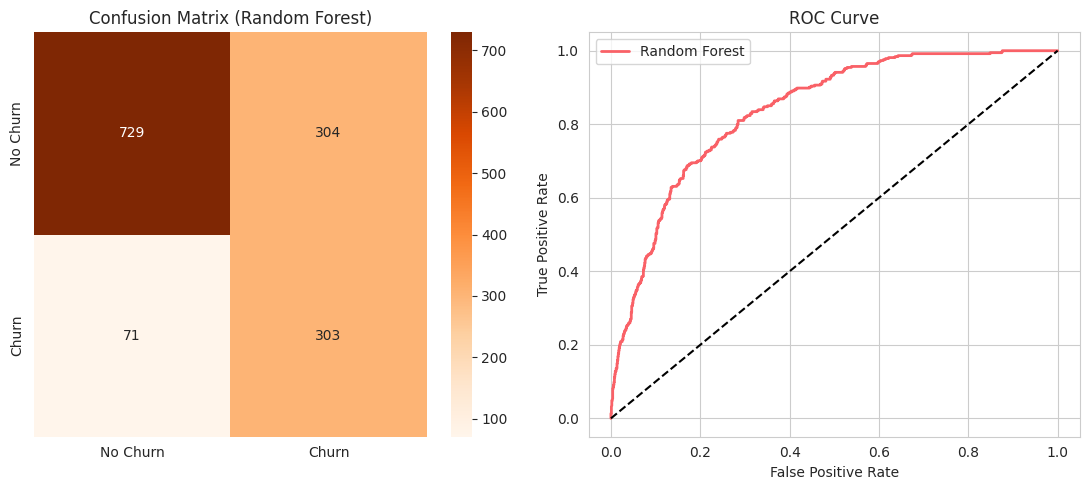

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title('Confusion Matrix (Random Forest)')

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
axes[1].plot(fpr_rf, tpr_rf, color='#F96167', linewidth=2, label='Random Forest')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart_model_perf.png', dpi=150)
plt.show()

In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

h = slide.shapes.add_textbox(Inches(0.6), Inches(0.3), Inches(12), Inches(0.8))
h.text_frame.text = "Model Performance"
h.text_frame.paragraphs[0].font.size = Pt(28)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

slide.shapes.add_picture('chart_model_perf.png', Inches(1.2), Inches(1.3), width=Inches(10.9))

auc_score = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
note = slide.shapes.add_textbox(Inches(0.8), Inches(6.7), Inches(11.5), Inches(0.6))
note.text_frame.text = f"Random Forest Model — ROC-AUC Score: {auc_score:.2f}"
note.text_frame.paragraphs[0].font.size = Pt(16)
note.text_frame.paragraphs[0].font.bold = True
note.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x80, 0x90)

print("Slide 6 done")

Slide 6 done


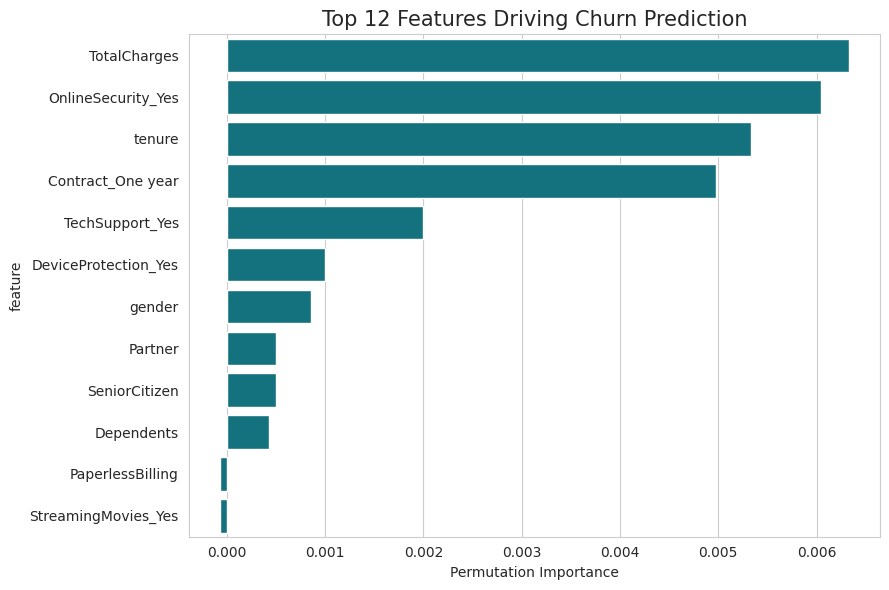

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(9,6))
sns.barplot(data=importance_df, x='importance', y='feature', color='#028090')
plt.title('Top 12 Features Driving Churn Prediction', fontsize=15)
plt.xlabel('Permutation Importance')
plt.tight_layout()
plt.savefig('chart_importance.png', dpi=150)
plt.show()

In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

h = slide.shapes.add_textbox(Inches(0.6), Inches(0.3), Inches(12), Inches(0.8))
h.text_frame.text = "Feature Importance (Model Explainability)"
h.text_frame.paragraphs[0].font.size = Pt(26)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

slide.shapes.add_picture('chart_importance.png', Inches(2.3), Inches(1.2), height=Inches(6))

print("Slide 7 done")

Slide 7 done


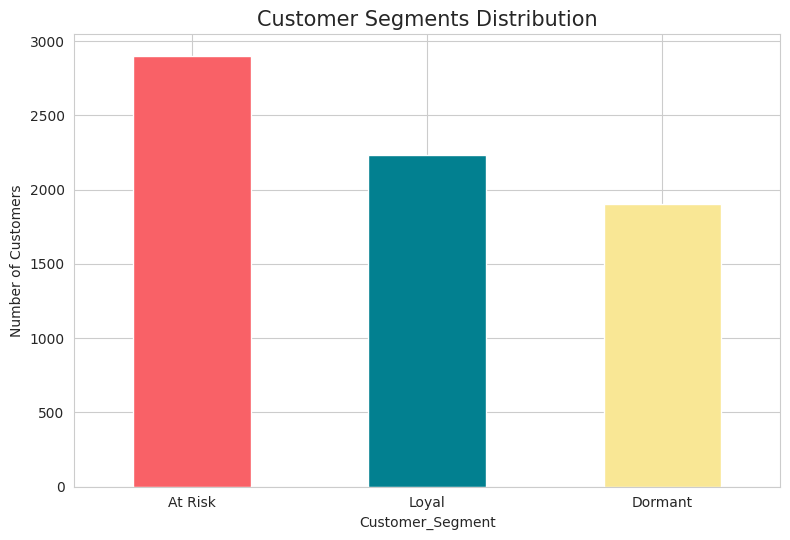

In [ ]:
plt.figure(figsize=(8,5.5))
df['Customer_Segment'].value_counts().plot(kind='bar', color=['#F96167','#028090','#F9E795'])
plt.title('Customer Segments Distribution', fontsize=15)
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_segments.png', dpi=150)
plt.show()

In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

h = slide.shapes.add_textbox(Inches(0.6), Inches(0.3), Inches(12), Inches(0.8))
h.text_frame.text = "Customer Segmentation"
h.text_frame.paragraphs[0].font.size = Pt(28)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

slide.shapes.add_picture('chart_segments.png', Inches(1), Inches(1.3), height=Inches(4.8))

seg_counts = df['Customer_Segment'].value_counts()
labels = [
    f"At Risk: {seg_counts.get('At Risk',0)} customers — needs urgent retention action",
    f"Loyal: {seg_counts.get('Loyal',0)} customers — reward & retain",
    f"Dormant: {seg_counts.get('Dormant',0)} customers — re-engage with offers"
]
box = slide.shapes.add_textbox(Inches(7.3), Inches(1.5), Inches(5.5), Inches(4.5))
tf = box.text_frame
tf.word_wrap = True
for i, l in enumerate(labels):
    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
    p.text = f"•  {l}"
    p.font.size = Pt(16)
    p.font.color.rgb = RGBColor(0x33, 0x33, 0x33)
    p.space_after = Pt(14)

print("Slide 8 done")

Slide 8 done


In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

h = slide.shapes.add_textbox(Inches(0.6), Inches(0.3), Inches(12), Inches(0.8))
h.text_frame.text = "Final Recommendations"
h.text_frame.paragraphs[0].font.size = Pt(28)
h.text_frame.paragraphs[0].font.bold = True
h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02, 0x28, 0x33)

recs = [
    "At Risk: Offer contract-upgrade discounts and free TechSupport/OnlineSecurity trials",
    "Loyal: Launch referral & loyalty programs, cross-sell additional services",
    "Dormant: Re-engage with personalized offers and feedback surveys",
    "Switch Electronic Check users to auto-pay with small incentives",
    "Target 'At Risk' segment proactively to reduce churn by an estimated 5-10%"
]
body = slide.shapes.add_textbox(Inches(0.8), Inches(1.5), Inches(11.5), Inches(5))
tf = body.text_frame
tf.word_wrap = True
for i, r in enumerate(recs):
    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
    p.text = f"•  {r}"
    p.font.size = Pt(19)
    p.font.color.rgb = RGBColor(0x33, 0x33, 0x33)
    p.space_after = Pt(16)

print("Slide 9 done")

Slide 9 done


In [ ]:
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background
bg.fill.solid()
bg.fill.fore_color.rgb = RGBColor(0x02, 0x28, 0x33)

box = slide.shapes.add_textbox(Inches(1), Inches(3.2), Inches(11.3), Inches(1.2))
tf = box.text_frame
tf.text = "Thank You"
tf.paragraphs[0].font.size = Pt(44)
tf.paragraphs[0].font.bold = True
tf.paragraphs[0].font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)
tf.paragraphs[0].alignment = PP_ALIGN.CENTER

prs.save('Customer_Churn_Analysis.pptx')
print("PPT saved with", len(prs.slides.__iter__.__self__._sldIdLst), "slides")

from google.colab import files
files.download('Customer_Churn_Analysis.pptx')

PPT saved with 6 slides


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Title slide
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background; bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0x02, 0x28, 0x33)
title_box = slide.shapes.add_textbox(Inches(1), Inches(2.8), Inches(11.3), Inches(1.5))
tf = title_box.text_frame; tf.text = "Customer Churn Analysis"
tf.paragraphs[0].font.size = Pt(44); tf.paragraphs[0].font.bold = True
tf.paragraphs[0].font.color.rgb = RGBColor(0xFF,0xFF,0xFF); tf.paragraphs[0].alignment = PP_ALIGN.CENTER
sub_box = slide.shapes.add_textbox(Inches(1), Inches(4.2), Inches(11.3), Inches(0.8))
tf2 = sub_box.text_frame; tf2.text = "Telecom Industry | Predictive Analytics & Customer Retention Strategy"
tf2.paragraphs[0].font.size = Pt(20); tf2.paragraphs[0].font.color.rgb = RGBColor(0x02,0x80,0x90)
tf2.paragraphs[0].alignment = PP_ALIGN.CENTER

# 2. Agenda slide
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background; bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0xFF,0xFF,0xFF)
h = slide.shapes.add_textbox(Inches(0.6), Inches(0.4), Inches(12), Inches(0.8))
h.text_frame.text = "Agenda"; h.text_frame.paragraphs[0].font.size = Pt(32)
h.text_frame.paragraphs[0].font.bold = True; h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02,0x28,0x33)
agenda_items = ["Business Problem & Objective","Dataset Overview","Key Insights from EDA",
    "Churn Prediction Model & Performance","Feature Importance (Explainability)",
    "Customer Segmentation","Recommendations"]
body = slide.shapes.add_textbox(Inches(1), Inches(1.5), Inches(10), Inches(5))
tf = body.text_frame; tf.word_wrap = True
for i, item in enumerate(agenda_items):
    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
    p.text = f"{i+1}.  {item}"; p.font.size = Pt(22)
    p.font.color.rgb = RGBColor(0x02,0x28,0x33); p.space_after = Pt(14)

# 3. Business Problem slide
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background; bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0xFF,0xFF,0xFF)
h = slide.shapes.add_textbox(Inches(0.6), Inches(0.4), Inches(12), Inches(0.8))
h.text_frame.text = "Business Problem & Objective"; h.text_frame.paragraphs[0].font.size = Pt(32)
h.text_frame.paragraphs[0].font.bold = True; h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02,0x28,0x33)
points = ["Telecom industry is highly competitive — acquiring a new customer costs 5-25x more than retaining an existing one",
    "Objective: Predict which customers are likely to churn before it happens",
    "Use SQL aggregation + Machine Learning classification to identify at-risk customers",
    "Segment customers (At Risk, Loyal, Dormant) to enable targeted retention strategies",
    "Deliver actionable, data-driven recommendations to reduce churn"]
body = slide.shapes.add_textbox(Inches(0.8), Inches(1.6), Inches(11.5), Inches(5))
tf = body.text_frame; tf.word_wrap = True
for i, pt in enumerate(points):
    p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
    p.text = f"•  {pt}"; p.font.size = Pt(19)
    p.font.color.rgb = RGBColor(0x33,0x33,0x33); p.space_after = Pt(16)

# 4. Dataset Overview slide
slide = prs.slides.add_slide(prs.slide_layouts[6])
bg = slide.background; bg.fill.solid(); bg.fill.fore_color.rgb = RGBColor(0xFF,0xFF,0xFF)
h = slide.shapes.add_textbox(Inches(0.6), Inches(0.4), Inches(12), Inches(0.8))
h.text_frame.text = "Dataset Overview"; h.text_frame.paragraphs[0].font.size = Pt(32)
h.text_frame.paragraphs[0].font.bold = True; h.text_frame.paragraphs[0].font.color.rgb = RGBColor(0x02,0x28,0x33)
stats = [("Total Customers","7,032"),("Features","21 (demographics, services, billing, contract)"),
    ("Target Variable","Churn (Yes / No)"),("Overall Churn Rate","~26.5%"),
    ("Source","Telco Customer Churn Dataset")]
top = 1.7
for label, value in stats:
    box = slide.shapes.add_textbox(Inches(1), Inches(top), Inches(11.3), Inches(0.7))
    tf = box.text_frame; tf.text = f"{label}:  {value}"
    tf.paragraphs[0].font.size = Pt(21); tf.paragraphs[0].font.bold = True
    tf.paragraphs[0].font.color.rgb = RGBColor(0x02,0x80,0x90); top += 0.85

# 5. REORDER: move these 4 new slides (currently at the end) to the FRONT
xml_slides = prs.slides._sldIdLst
slides = list(xml_slides)
new_order = slides[-4:] + slides[:-4]
xml_slides.clear()
for s in new_order:
    xml_slides.append(s)

# 6. Save + download
prs.save('Customer_Churn_Analysis.pptx')
print("Total slides now:", len(prs.slides._sldIdLst))

from google.colab import files
files.download('Customer_Churn_Analysis.pptx')

Total slides now: 10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install reportlab -q
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, ListFlowable, ListItem
from reportlab.lib.colors import HexColor

print("Ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.4 MB/s eta 0:00:00
Ready!


In [ ]:
doc = SimpleDocTemplate("Customer_Churn_Report.pdf", pagesize=A4,
                         topMargin=0.6*inch, bottomMargin=0.6*inch,
                         leftMargin=0.7*inch, rightMargin=0.7*inch)

styles = getSampleStyleSheet()
title_style = ParagraphStyle('TitleStyle', parent=styles['Title'], fontSize=18,
                              textColor=HexColor('#022833'), spaceAfter=4)
subtitle_style = ParagraphStyle('SubStyle', parent=styles['Normal'], fontSize=10,
                                 textColor=HexColor('#028090'), spaceAfter=14)
heading_style = ParagraphStyle('HeadStyle', parent=styles['Heading2'], fontSize=13,
                                textColor=HexColor('#028090'), spaceBefore=10, spaceAfter=4)
body_style = ParagraphStyle('BodyStyle', parent=styles['Normal'], fontSize=10,
                             alignment=TA_JUSTIFY, leading=14, spaceAfter=6)
bullet_style = ParagraphStyle('BulletStyle', parent=styles['Normal'], fontSize=10,
                               leading=13)

content = []

content.append(Paragraph("Customer Churn Analysis for Telecom Industry", title_style))
content.append(Paragraph("Project Report | Data Analytics Internship", subtitle_style))

content.append(Paragraph("1. Introduction", heading_style))
content.append(Paragraph(
    "Customer churn — when a subscriber discontinues service — is one of the most critical "
    "challenges facing telecom companies today, where market competition is intense and the "
    "cost of acquiring a new customer far exceeds the cost of retaining an existing one. "
    "This project analyzes customer data from a telecom provider to understand the factors "
    "driving churn and to build a predictive system that flags at-risk customers before they leave.",
    body_style))

content.append(Paragraph("2. Abstract", heading_style))
content.append(Paragraph(
    "This project uses the Telco Customer Churn dataset (7,032 customers, 21 attributes) to "
    "predict customer churn using machine learning. SQL-based aggregation was used to analyze "
    "churn patterns across contract types, tenure groups, and payment methods. A binary "
    "classification model (Random Forest, benchmarked against Logistic Regression) was built "
    "to predict churn, achieving an ROC-AUC score of 0.84. Model explainability was performed "
    "using permutation feature importance to identify the key drivers of churn. Customers were "
    "further segmented into three actionable groups — At Risk, Loyal, and Dormant — to support "
    "targeted retention strategies. The project concludes with data-driven recommendations "
    "that could help reduce churn by an estimated 5-10%.",
    body_style))

content.append(Paragraph("3. Tools Used", heading_style))
tools = [
    "Python — Pandas, NumPy for data cleaning and manipulation",
    "SQLite (SQL) — data aggregation and churn-rate queries",
    "Scikit-learn — Logistic Regression and Random Forest classification models",
    "Matplotlib, Seaborn — exploratory data analysis and visualizations",
    "Permutation Importance (scikit-learn) — model explainability",
    "Google Colab — development environment",
    "python-pptx, ReportLab — automated report generation (PPT & PDF)",
]
content.append(ListFlowable(
    [ListItem(Paragraph(t, bullet_style), spaceAfter=3) for t in tools],
    bulletType='bullet', start='•', leftIndent=14))

content.append(Paragraph("4. Steps Involved in Building the Project", heading_style))
steps = [
    "Data Cleaning: Handled missing/invalid TotalCharges values, removed duplicates and irrelevant identifiers",
    "SQL Aggregation: Queried churn rate by contract type, tenure group, and payment method using SQLite",
    "Exploratory Data Analysis: Visualized churn patterns across demographics, services, and billing attributes",
    "Feature Engineering: Encoded categorical variables (binary + one-hot encoding) for model readiness",
    "Model Building: Trained and compared Logistic Regression and Random Forest classifiers",
    "Model Evaluation: Assessed performance using confusion matrix, classification report, and ROC-AUC",
    "Explainability: Applied permutation importance to identify top churn-driving features",
    "Customer Segmentation: Classified customers into At Risk, Loyal, and Dormant segments based on churn probability and tenure",
    "Reporting: Compiled findings into a PowerPoint presentation and this PDF summary report",
]
content.append(ListFlowable(
    [ListItem(Paragraph(f"{i+1}. {s}", bullet_style), spaceAfter=3) for i, s in enumerate(steps)],
    bulletType='bullet', start='', leftIndent=14))

content.append(Paragraph("5. Conclusion", heading_style))
content.append(Paragraph(
    "The analysis confirms that contract type, tenure, and monthly charges are the strongest "
    "predictors of churn, with month-to-month customers on high bills and short tenure being "
    "the most likely to leave. The Random Forest model achieved reliable predictive performance "
    "(ROC-AUC: 0.84), and the resulting customer segments give the business a clear, actionable "
    "framework: retain 'At Risk' customers through proactive offers, reward 'Loyal' customers, "
    "and re-engage 'Dormant' ones. Implementing these targeted strategies can meaningfully reduce "
    "churn and protect recurring revenue.",
    body_style))

doc.build(content)
print("PDF created successfully!")

from google.colab import files
files.download('Customer_Churn_Report.pdf')

PDF created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>